# **Task 4 - Business Insights Report (EDA)**
## Marketing Campaign Data Analysis

This project performs Exploratory Data Analysis (EDA) on a marketing campaign dataset to identify customer behavior, campaign performance, and business insights.

Importing Required Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load dataset
df = pd.read_excel('/content/marketing_campaign_datset.xlsx')
# Display first 5 rows
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


Understanding the Dataset

In [6]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

Checking Missing Values

In [7]:
# Check missing values
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


Handling Missing Values

In [8]:
# Fill missing Income values with median
df['Income'].fillna(df['Income'].median(), inplace=True)

# Verify again
df.isnull().sum()

/tmp/ipykernel_11115/1153230771.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


Checking Duplicate Rows

In [9]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

Converting Date Columns

In [10]:
# Convert Dt_Customer to datetime format
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

# Check updated datatype
df['Dt_Customer'].dtype

dtype('<M8[ns]')

Basic Statistical Summary

In [11]:
# Statistical summary
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52237.975446,0.444196,0.506250,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35538.750000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68289.750000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000
std,3246.662198,11.984069,25037.955891,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274


Income Distribution Analysis

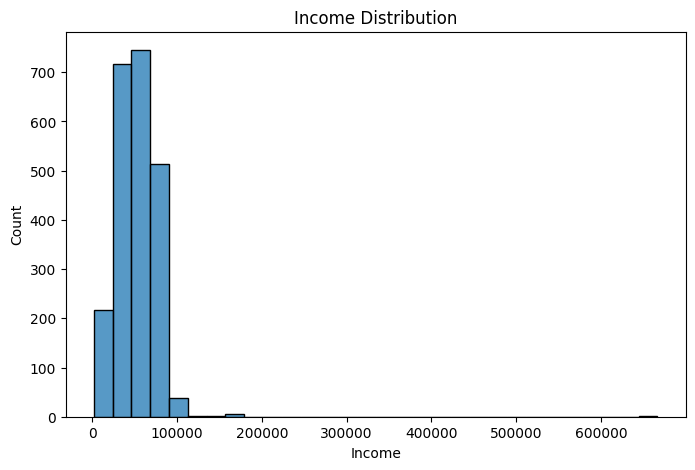

In [14]:
# Income distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Income'], bins=30)

plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Count')

plt.show()

Customer Spending Analysis

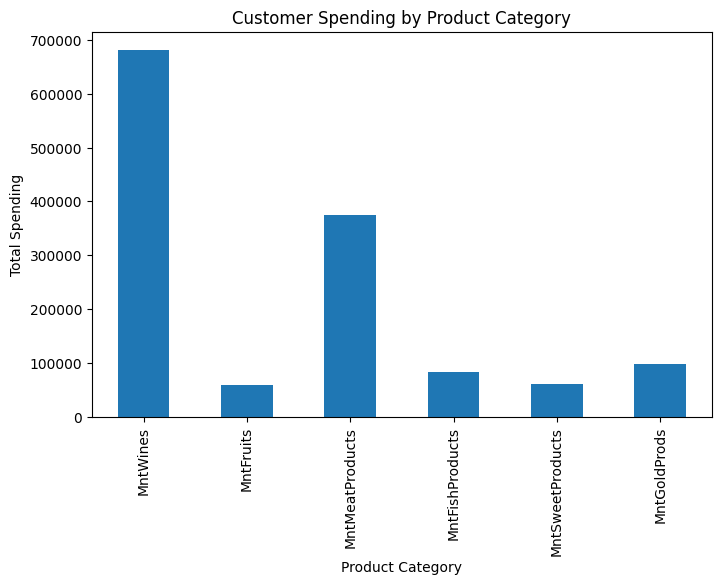

In [15]:
# Top product spending categories
spending = df[['MntWines','MntFruits','MntMeatProducts',
               'MntFishProducts','MntSweetProducts',
               'MntGoldProds']].sum()

plt.figure(figsize=(8,5))
spending.plot(kind='bar')

plt.title('Customer Spending by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Spending')

plt.show()

Campaign Acceptance Analysis

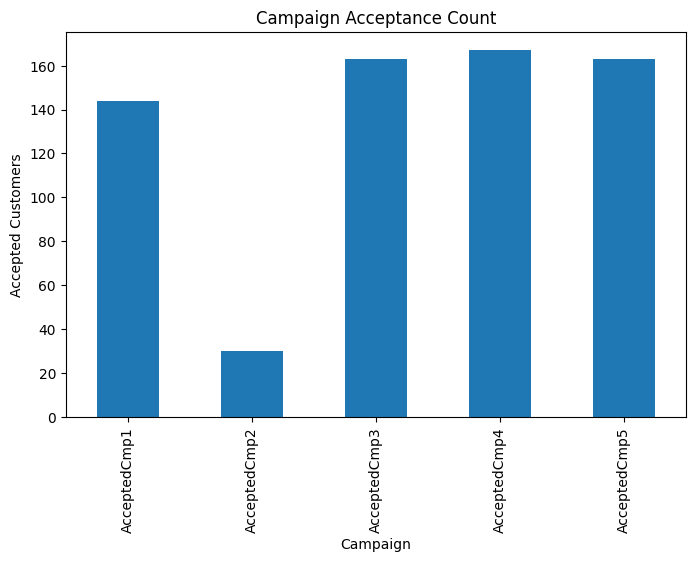

In [16]:
# Total campaign acceptance
campaigns = df[['AcceptedCmp1','AcceptedCmp2',
                'AcceptedCmp3','AcceptedCmp4',
                'AcceptedCmp5']].sum()

plt.figure(figsize=(8,5))
campaigns.plot(kind='bar')

plt.title('Campaign Acceptance Count')
plt.xlabel('Campaign')
plt.ylabel('Accepted Customers')

plt.show()

Customer Response Analysis

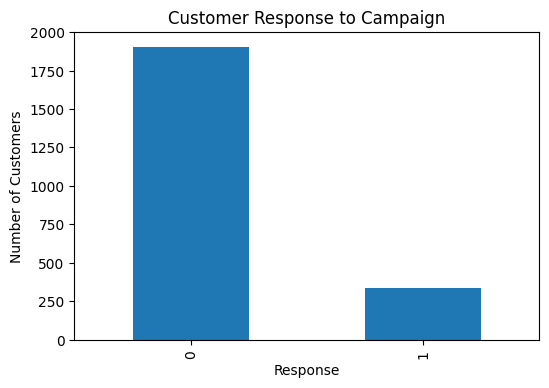

In [17]:
# Customer response count
response_counts = df['Response'].value_counts()

plt.figure(figsize=(6,4))
response_counts.plot(kind='bar')

plt.title('Customer Response to Campaign')
plt.xlabel('Response')
plt.ylabel('Number of Customers')

plt.show()

# Final Insights and Conclusion

## Key Findings

- Most customers belong to the medium-income group.
- Wine products generated the highest customer spending.
- Meat products were the second most purchased category.
- Campaign 4 received the highest customer acceptance.
- Majority of customers did not respond positively to marketing campaigns.

## Business Recommendations

- Focus marketing campaigns on high-spending product categories like Wines and Meat products.
- Improve customer targeting strategies to increase campaign response rates.
- Provide personalized offers to medium-income customers for better engagement.
- Analyze why certain campaigns performed better and replicate successful strategies.

## Conclusion

This Exploratory Data Analysis (EDA) project helped identify customer purchasing behavior, campaign effectiveness, and spending trends. The analysis provides valuable business insights that can support better marketing and customer engagement decisions.